#### Query: (hand or gripper) and (manipulation or grasping or grip or skill)  
#### Years: 2019-2025
#### Citation: 1+
#### Publisher: IEEE

In [1]:
# open json file
import json
import matplotlib.pyplot as plt
import numpy as np

all_data = []
def open_json_file(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

all_articles=[]

for ind in range(20):
    data=open_json_file("data/data_"+str(ind)+".json")
    for j in data["articles"]:
        all_articles.append(j)

In [2]:
print("Overall Number of Articles: ",len(all_articles))

Overall Number of Articles:  3883


In [3]:
keywords_0=['hand', 'gripper']
keywords_1=['manipulation', 'grasping' , 'grip', 'skill']

keywords_used=[]
terms_used=[]
articles_filtered = []
articles_filtered_titles = []
for article in all_articles:
    if "citing_paper_count" in article.keys():
        if article["citing_paper_count"] > 0:
            # if keywords in index_terms
            flag_0=False
            flag_1=False
            all_terms=[]
            for j in article["index_terms"].values():
                terms=[x.lower() for x in j["terms"]]
                all_terms+=terms  # ieee and authors terms
            all_terms=np.unique(all_terms)
            for l in keywords_0:
                for k in all_terms:
                    if l in k:
                        flag_0=True
                        keywords_used.append(l)
                        terms_used.append(k)
                        break    
            for l in keywords_1:
                for k in all_terms:
                    if l in k:
                        flag_1=True
                        keywords_used.append(l)
                        terms_used.append(k)
                        break
            if flag_0 and flag_1:
                articles_filtered.append(article)
                articles_filtered_titles.append(article["title"])

terms_used=np.unique(terms_used)

In [4]:
print("Overall filtered Articles: ",len(articles_filtered))

Overall filtered Articles:  659


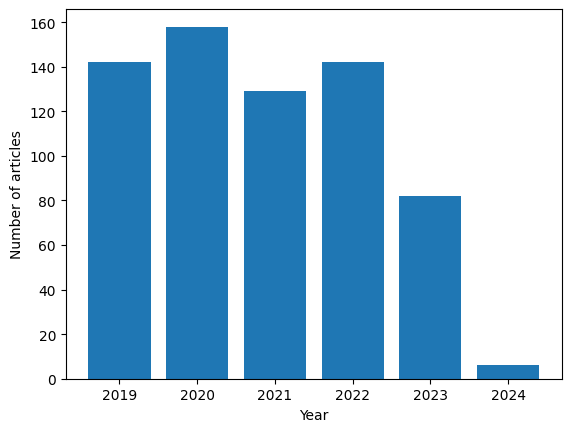

In [5]:
years=[]
for i in articles_filtered:
    years.append(i["publication_year"])
plt.bar(*np.unique(years, return_counts=True))
# set x-axis label
plt.xlabel('Year')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

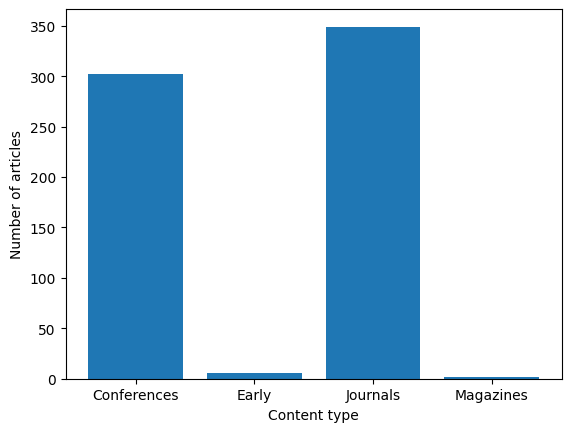

In [6]:
content_type=[]
for i in articles_filtered:
    content_type.append(i["content_type"].split()[0])
plt.bar(*np.unique(content_type, return_counts=True))
# set x-axis label
plt.xlabel('Content type')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

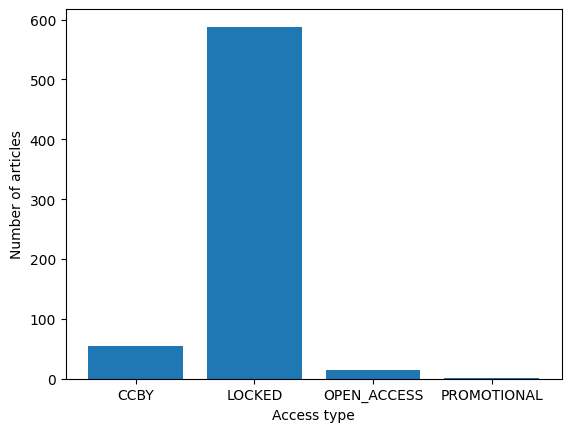

In [7]:
access_type=[]
for i in articles_filtered:
    access_type.append(i["access_type"].split()[0])
plt.bar(*np.unique(access_type, return_counts=True))
# set x-axis label
plt.xlabel('Access type')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

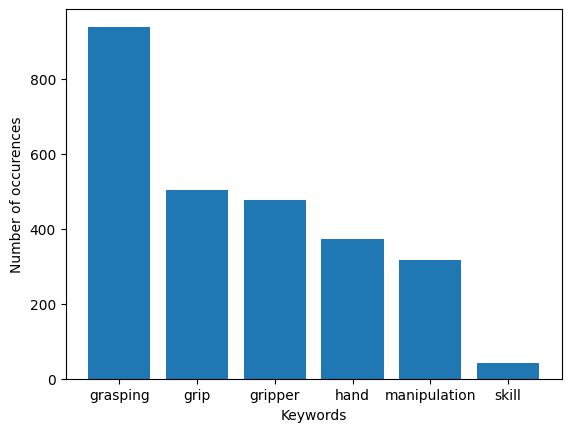

In [8]:
plt.bar(*np.unique(keywords_used, return_counts=True))
# set x-axis label
plt.xlabel('Keywords')
# set y-axis label
plt.ylabel('Number of occurences')
plt.show()